In [ ]:
import boto3
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


inspection_id = "0AQQZFV2ALD" #fhr13-02
angle_profiles = ["0"]
num_tracks = 24
run_number = "13-02"
results_dir = f"/mnt/f/data-files/{inspection_id}/track_runs/dent_ultrasound/"


In [ ]:
root = Path(results_dir)
data_files = sorted(root.rglob("*.parquet"))

In [ ]:
len(data_files)

In [ ]:

df = pd.read_parquet(data_files[-1000])
#remove attn_map columns
df = df.drop(columns=[col for col in df.columns if "attn_map" in col])
df.head()
#13488222

In [ ]:
def keep_confident(df, threshold=0.5, score_col='dent_prob'):
    """
    Keep only rows where crack_score is greater than the given threshold.
    """
    return df[df[score_col] > threshold].reset_index(drop=True)

## Create a DataFrame for each profile and track and range
def create_df(track_idx, threshold = 0.7, frame_range=None):
    if frame_range is None:
        data_files_range = [f for f in data_files if f.parent.parent.parent.name == f"track_{track_idx:02d}"]
    else:
        data_files_range = [f for f in data_files if f.parent.parent.parent.name == f"track_{track_idx:02d}" and f.name.startswith(f"frames_{frame_range[0]:012d}_{frame_range[1]:012d}")]


    dfs = []
    for path in data_files_range:
        df = pd.read_parquet(path)
        df = keep_confident(df, threshold=threshold, score_col='dent_prob')
        df = df.drop(columns=[col for col in df.columns if "attn_map" in col])
        dfs.append(df)

        # Handle case where all DataFrames were empty or had errors
    if not dfs:
        print(f"No valid data found for frame_range={frame_range}")
        return pd.DataFrame()
    
    return pd.concat(dfs) if len(dfs) > 1 else dfs[0]

In [ ]:
def analyze_frame_sequences(df, frame_col='frame_idx', range_col='frame_range', plot=True):
    """
    Analyze consecutive frame sequences in a DataFrame.
    
    Args:
        df: DataFrame with frame indices
        frame_col: column name containing frame indices
        range_col: name for the new range column
        plot: whether to show histogram of sequence lengths
    
    Returns:
        tuple: (df_with_ranges, num_unique_sequences, sequence_lengths)
    """
    if len(df) == 0:
        print("Empty DataFrame")
        return df.copy(), 0, []
    
    # # Sort by frame index and reset index
    # df_sorted = df.copy().sort_values(frame_col).reset_index(drop=True) #aleardy sorted
    df_sorted = df.copy()
    
    
    # Find breaks in consecutive sequences
    frame_diff = df_sorted[frame_col].diff()
    breaks = (frame_diff != 1) & (frame_diff.notna())
    
    # Assign range IDs - each break starts a new range
    range_ids = breaks.cumsum()
    
    # Create range labels and calculate sequence lengths
    range_labels = []
    sequence_lengths = []
    
    for range_id in range_ids.unique():
        mask = range_ids == range_id
        start_frame = df_sorted.loc[mask, frame_col].min()
        end_frame = df_sorted.loc[mask, frame_col].max()
        sequence_length = end_frame - start_frame + 1
        
        range_labels.append(f"{start_frame}_{end_frame}")
        sequence_lengths.append(sequence_length)
    
    # Map range IDs to labels
    range_mapping = dict(zip(range_ids.unique(), range_labels))
    df_sorted[range_col] = range_ids.map(range_mapping)
    
    # Number of unique sequences
    num_unique_sequences = len(range_labels)
    
    # Print summary
    print(f"Total frames: {len(df_sorted)}")
    print(f"Number of unique sequences: {num_unique_sequences}")
    print(f"Sequence lengths - Min: {min(sequence_lengths)}, Max: {max(sequence_lengths)}, Mean: {np.mean(sequence_lengths):.1f}")
    
    # Plot histogram if requested
    if plot:
        plt.figure(figsize=(10, 6))
        plt.hist(sequence_lengths, bins=max(1, min(50, num_unique_sequences//2)), 
                 color='skyblue', alpha=0.7, edgecolor='black')
        plt.title('Histogram of Consecutive Frame Sequence Lengths')
        plt.xlabel('Sequence Length (number of consecutive frames)')
        plt.ylabel('Frequency')
        plt.grid(True, alpha=0.3)
        
        # Add statistics text
        plt.text(0.7, 0.9, f'Total sequences: {num_unique_sequences}\n'
                           f'Mean length: {np.mean(sequence_lengths):.1f}\n'
                           f'Max length: {max(sequence_lengths)}', 
                 transform=plt.gca().transAxes, 
                 bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.5))
        
        plt.tight_layout()
        plt.show()
    
    return df_sorted, num_unique_sequences, sequence_lengths

In [ ]:
def merge_sequences_to_single_row(df_with_ranges, range_col='frame_range', inspection_id=None):
    """
    Merge rows by sequence to have one row per frame_range sequence.
    
    Args:
        df_with_ranges: DataFrame with frame_range column and detection data
        range_col: column name containing frame range identifiers
        inspection_id: inspection ID to add to the output (if not in df)
    
    Returns:
        DataFrame with one row per sequence containing aggregated information
    """
    if len(df_with_ranges) == 0:
        return pd.DataFrame()
    
    # Group by frame_range and aggregate
    agg_dict = {
        'frame_idx': ['min', 'max', 'count'],
        'dent_prob': ['mean', 'max', 'min', 'std'],
        'timer_tick': ['min', 'max'],
        'odometer_tick': ['min', 'max'],
        'clip_id': 'first',
        'track_id': 'first'
    }
    
    # Add inspection_id if it exists in the dataframe
    if 'inspection_id' in df_with_ranges.columns:
        agg_dict['inspection_id'] = 'first'
    
    sequence_summary = df_with_ranges.groupby(range_col).agg(agg_dict).round(4)
    
    # Flatten column names
    sequence_summary.columns = [f'{col[0]}_{col[1]}' if col[1] != '' else col[0] 
                               for col in sequence_summary.columns]
    
    # Reset index to make frame_range a regular column
    sequence_summary = sequence_summary.reset_index()
    
    # Add computed columns
    sequence_summary['sequence_length'] = sequence_summary['frame_idx_count']
    sequence_summary['frame_span'] = (sequence_summary['frame_idx_max'] - 
                                     sequence_summary['frame_idx_min'] + 1)
    sequence_summary['timer_span'] = (sequence_summary['timer_tick_max'] - 
                                     sequence_summary['timer_tick_min'])
    sequence_summary['odometer_span'] = (sequence_summary['odometer_tick_max'] - 
                                        sequence_summary['odometer_tick_min'])
    
    # Rename columns for clarity
    column_rename = {
        'frame_idx_min': 'start_frame',
        'frame_idx_max': 'end_frame', 
        'frame_idx_count': 'num_detections',
        'dent_prob_mean': 'avg_confidence',
        'dent_prob_max': 'max_confidence',
        'dent_prob_min': 'min_confidence',
        'dent_prob_std': 'confidence_std',
        'timer_tick_min': 'start_timer_tick',
        'timer_tick_max': 'end_timer_tick',
        'odometer_tick_min': 'start_odometer_tick',
        'odometer_tick_max': 'end_odometer_tick',
        'clip_id_first': 'clip_id',
        'track_id_first': 'track_id'
    }
    
    # Add inspection_id rename if it exists
    if 'inspection_id_first' in sequence_summary.columns:
        column_rename['inspection_id_first'] = 'inspection_id'
    
    sequence_summary = sequence_summary.rename(columns=column_rename)
    
    # Add inspection_id if provided and not in dataframe
    if inspection_id and 'inspection_id' not in sequence_summary.columns:
        sequence_summary['inspection_id'] = inspection_id
    
    # Reorder columns for better readability
    column_order = [
        'inspection_id', 'frame_range', 'clip_id', 'track_id',
        'start_frame', 'end_frame', 'sequence_length', 'frame_span', 'num_detections',
        'start_timer_tick', 'end_timer_tick', 'timer_span',
        'start_odometer_tick', 'end_odometer_tick', 'odometer_span',
        'avg_confidence', 'max_confidence', 'min_confidence', 'confidence_std'
    ]
    
    # Only keep columns that exist
    available_columns = [col for col in column_order if col in sequence_summary.columns]
    sequence_summary = sequence_summary[available_columns]
    
    print(f"Merged {len(df_with_ranges)} rows into {len(sequence_summary)} sequences")
    
    return sequence_summary

In [ ]:
from io import BytesIO

def save_df_to_s3_parquet(df, bucket_name, s3_key):
    """
    Save DataFrame to S3 as parquet file
    
    Args:
        df: DataFrame to save
        bucket_name: S3 bucket name
        s3_key: S3 key (path) for the file
    """
    # Convert DataFrame to parquet in memory
    parquet_buffer = BytesIO()
    df.to_parquet(parquet_buffer, index=False)
    parquet_buffer.seek(0)
    
    # Upload to S3
    s3_client = boto3.client('s3')
    s3_client.put_object(
        Bucket=bucket_name,
        Key=s3_key,
        Body=parquet_buffer.getvalue(),
        ContentType='application/octet-stream'
    )
    
    print(f"DataFrame saved to s3://{bucket_name}/{s3_key}")

Total frames: 329437
Number of unique sequences: 2994
Sequence lengths - Min: 1, Max: 4355, Mean: 110.0


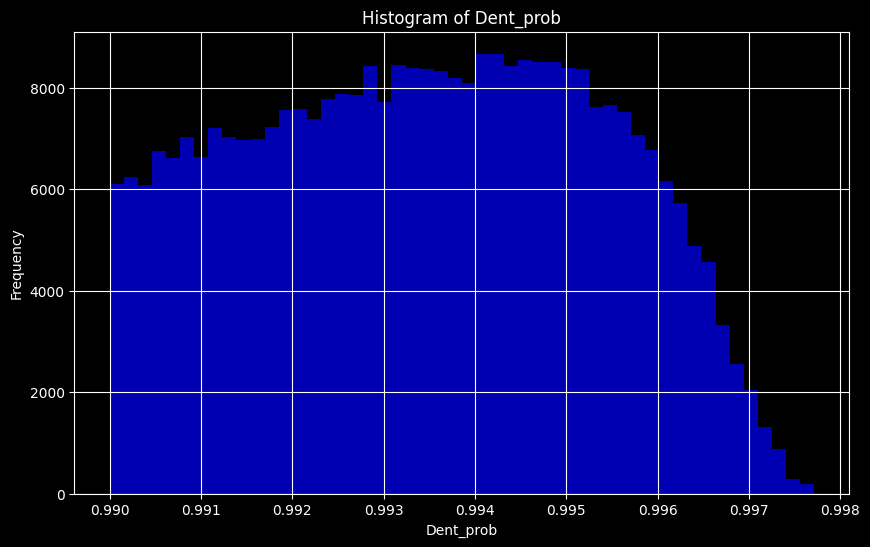

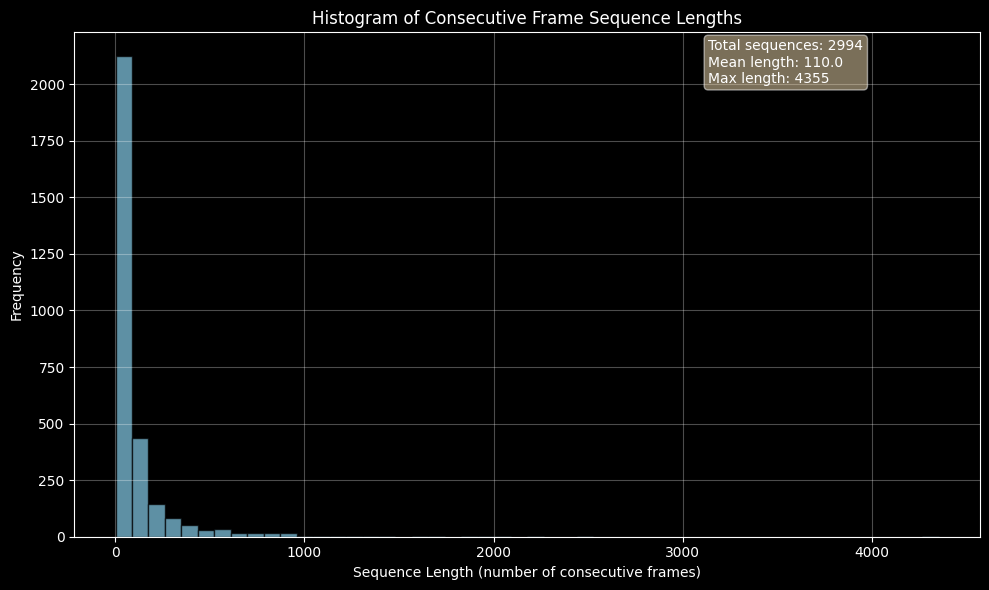

Merged 329437 rows into 2994 sequences
2994

Sequence Summary for track 0 and threshold 0.99:
Total sequences: 2994
Average sequence length: 110.0
Longest sequence: 4355 frames
Average confidence: 0.992
2994
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AQQZFV2ALD_track_0.parquet
No valid data found for frame_range=None
No data for track 1 at threshold 0.99, skipping.
Total frames: 313772
Number of unique sequences: 2868
Sequence lengths - Min: 1, Max: 3120, Mean: 109.4


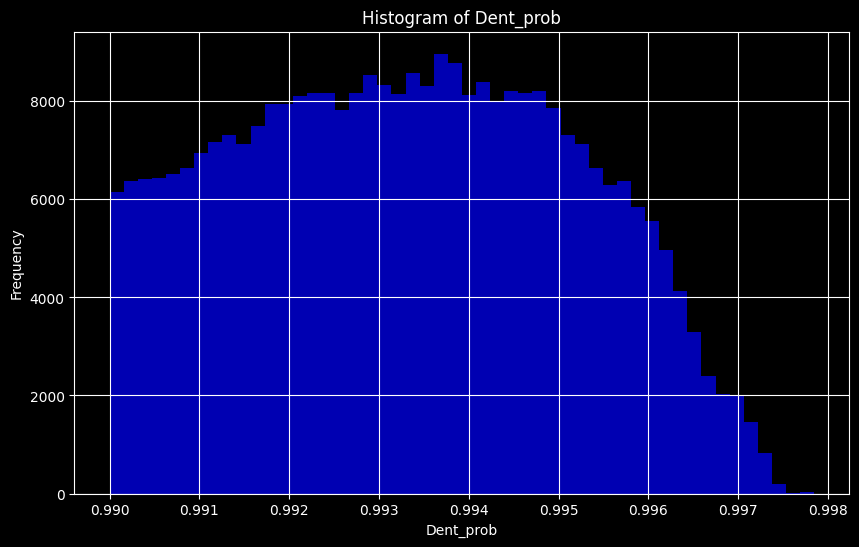

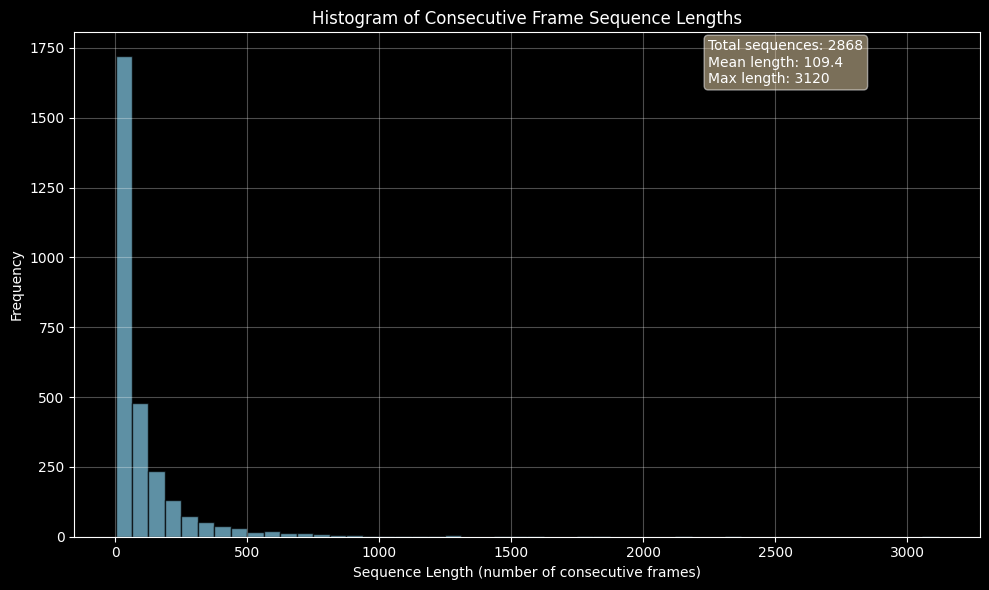

Merged 313772 rows into 2868 sequences
2868

Sequence Summary for track 2 and threshold 0.99:
Total sequences: 2868
Average sequence length: 109.4
Longest sequence: 3120 frames
Average confidence: 0.992
2868
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AQQZFV2ALD_track_2.parquet
Total frames: 300129
Number of unique sequences: 2867
Sequence lengths - Min: 1, Max: 4195, Mean: 104.7


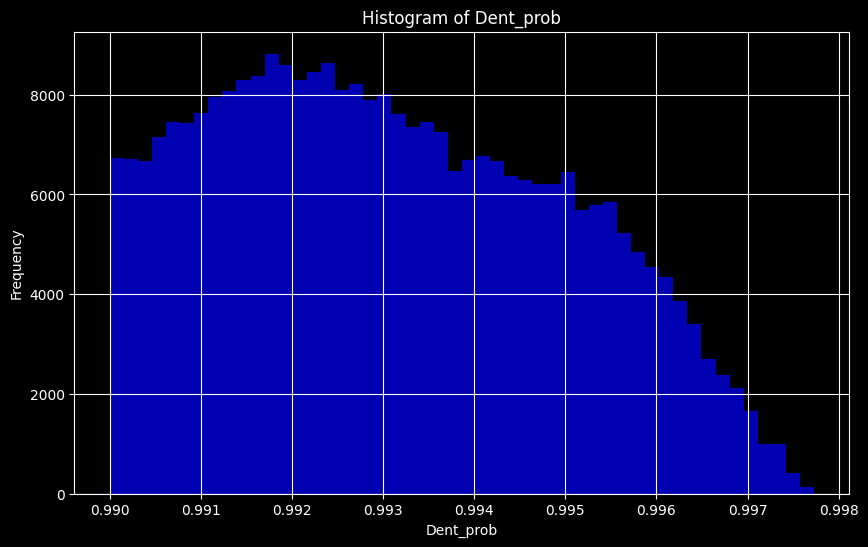

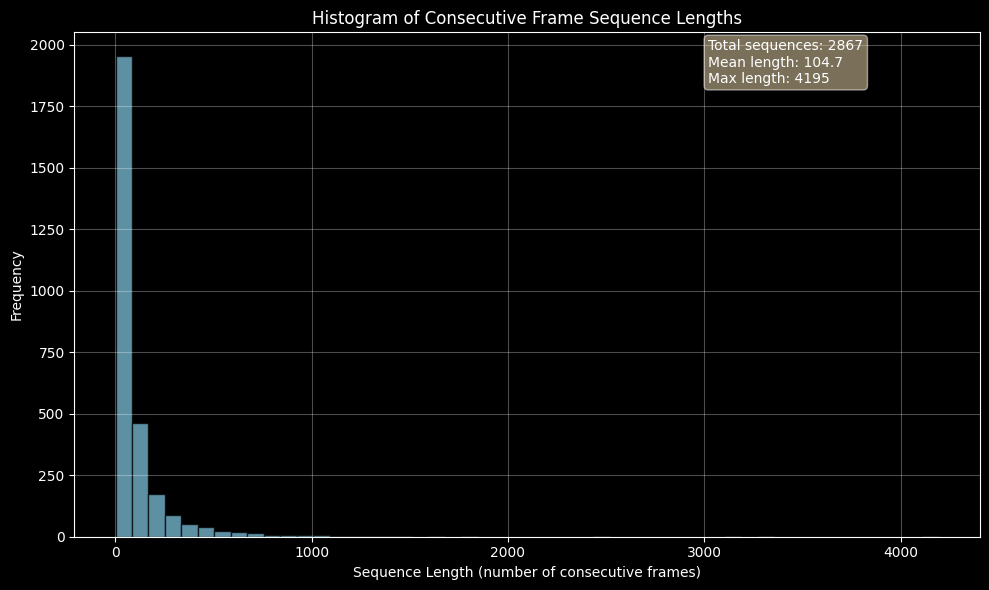

Merged 300129 rows into 2867 sequences
2867

Sequence Summary for track 3 and threshold 0.99:
Total sequences: 2867
Average sequence length: 104.7
Longest sequence: 4195 frames
Average confidence: 0.992
2867
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AQQZFV2ALD_track_3.parquet
Total frames: 295333
Number of unique sequences: 2790
Sequence lengths - Min: 1, Max: 3325, Mean: 105.9


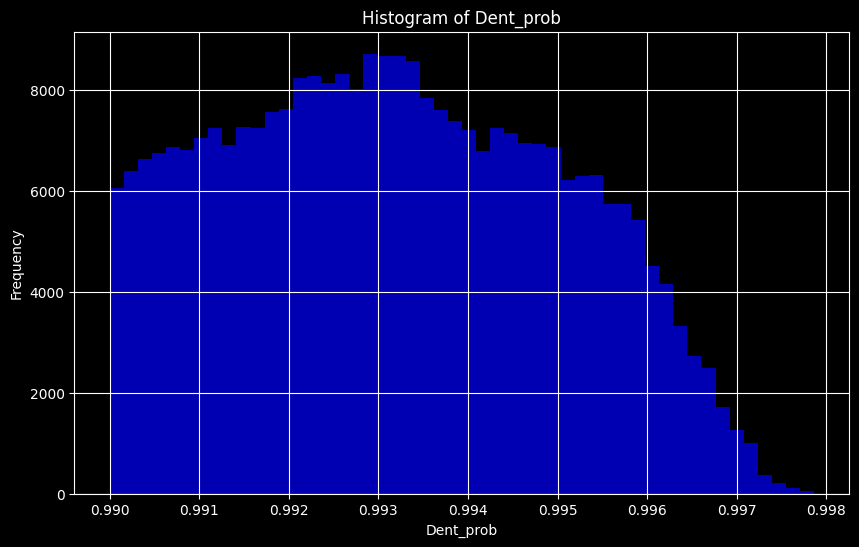

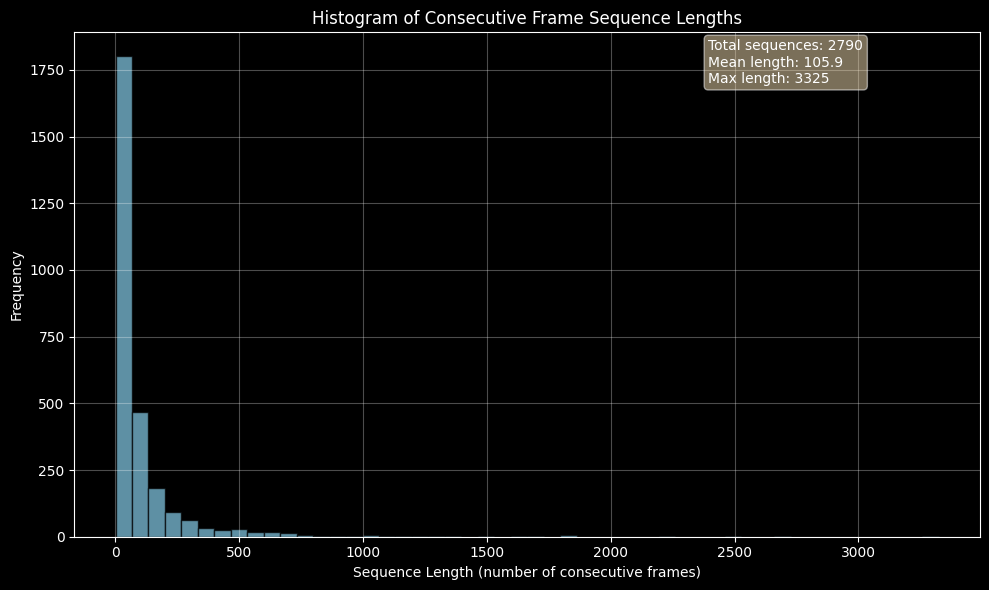

Merged 295333 rows into 2790 sequences
2790

Sequence Summary for track 4 and threshold 0.99:
Total sequences: 2790
Average sequence length: 105.9
Longest sequence: 3325 frames
Average confidence: 0.992
2790
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AQQZFV2ALD_track_4.parquet
Total frames: 324036
Number of unique sequences: 2804
Sequence lengths - Min: 1, Max: 5055, Mean: 115.6


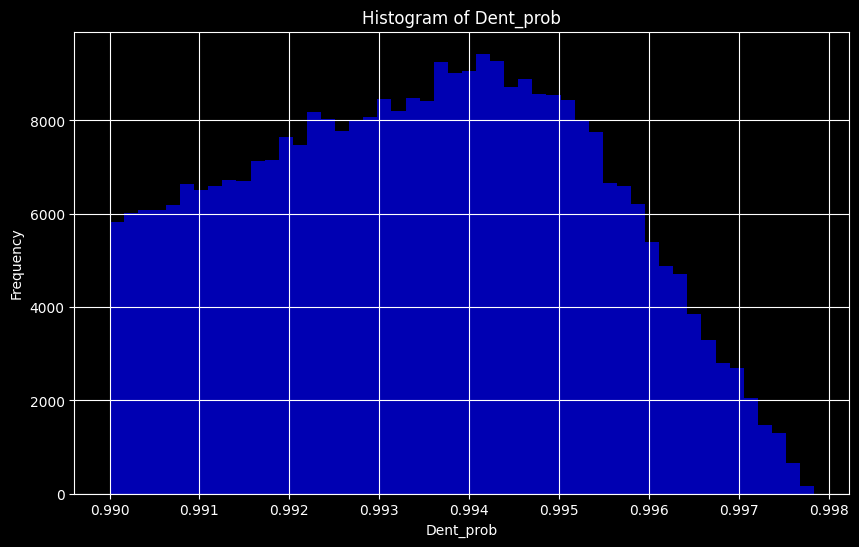

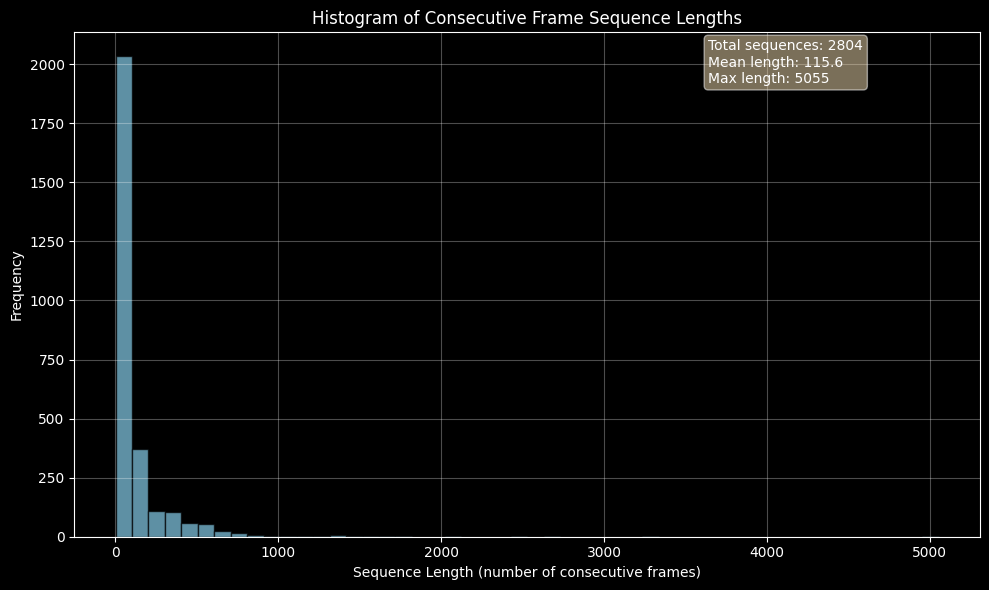

Merged 324036 rows into 2804 sequences
2804

Sequence Summary for track 5 and threshold 0.99:
Total sequences: 2804
Average sequence length: 115.6
Longest sequence: 5055 frames
Average confidence: 0.992
2804
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AQQZFV2ALD_track_5.parquet
Total frames: 527453
Number of unique sequences: 5500
Sequence lengths - Min: 1, Max: 8640, Mean: 95.9


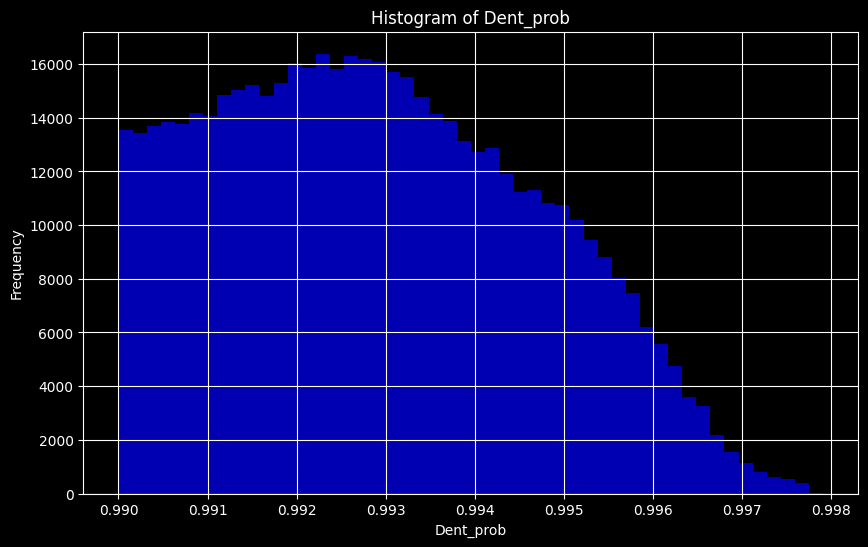

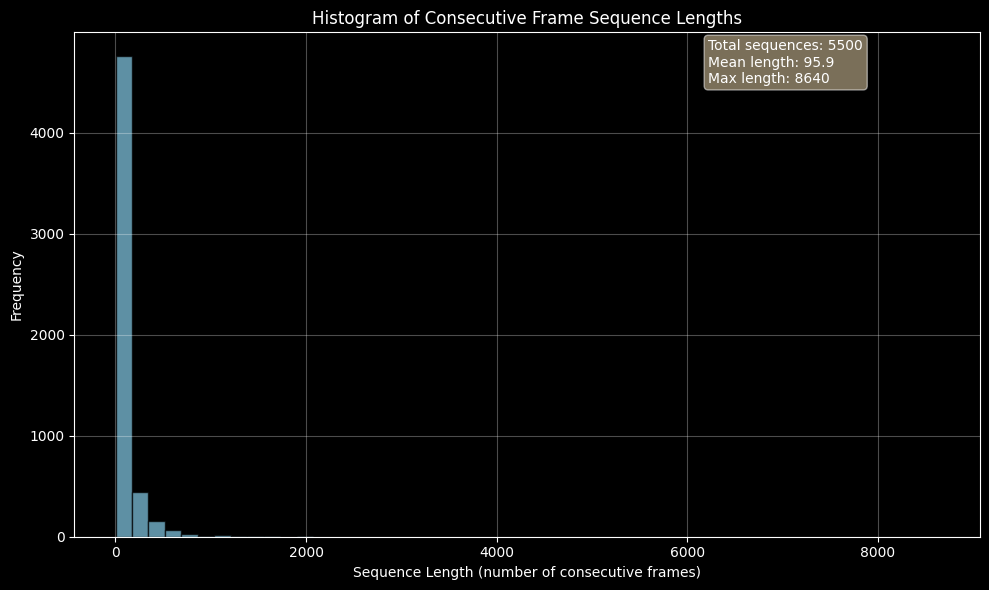

Merged 527453 rows into 5500 sequences
5500

Sequence Summary for track 6 and threshold 0.99:
Total sequences: 5500
Average sequence length: 95.9
Longest sequence: 8640 frames
Average confidence: 0.992
5500
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AQQZFV2ALD_track_6.parquet
Total frames: 328529
Number of unique sequences: 3063
Sequence lengths - Min: 1, Max: 5395, Mean: 107.3


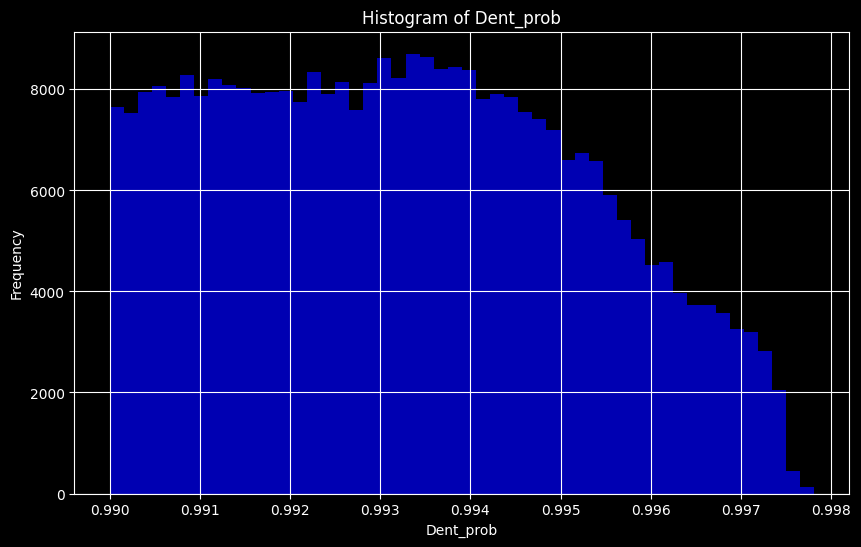

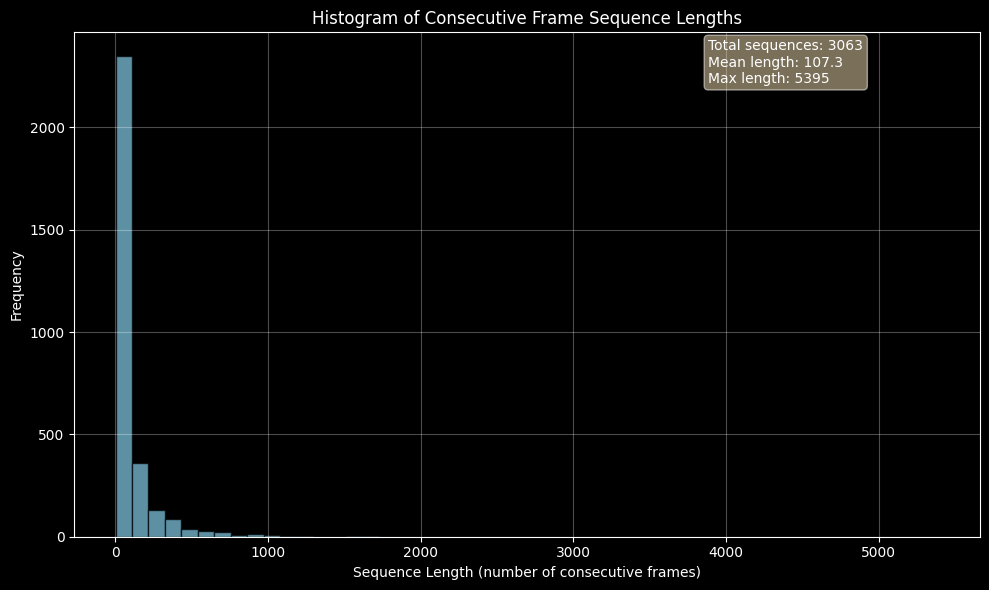

Merged 328529 rows into 3063 sequences
3063

Sequence Summary for track 7 and threshold 0.99:
Total sequences: 3063
Average sequence length: 107.3
Longest sequence: 5395 frames
Average confidence: 0.992
3063
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AQQZFV2ALD_track_7.parquet
No valid data found for frame_range=None
No data for track 8 at threshold 0.99, skipping.
Total frames: 696179
Number of unique sequences: 8408
Sequence lengths - Min: 1, Max: 6440, Mean: 82.8


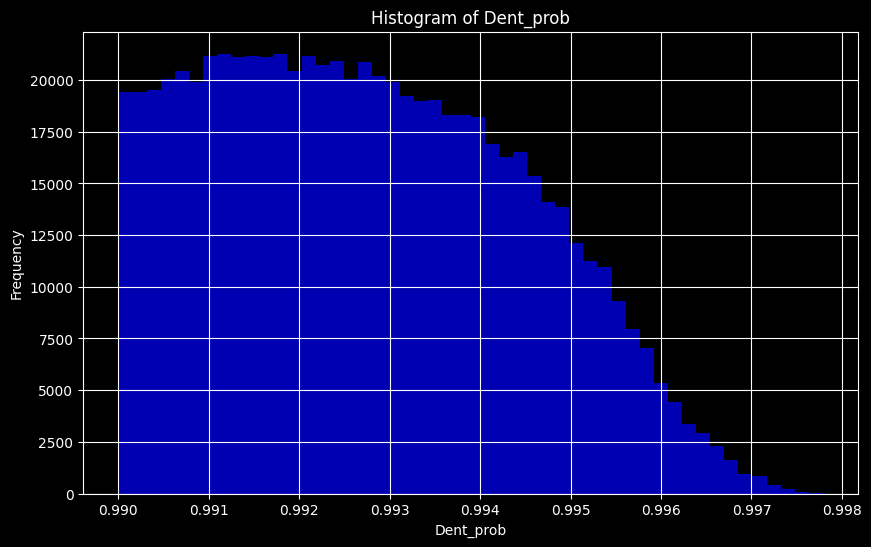

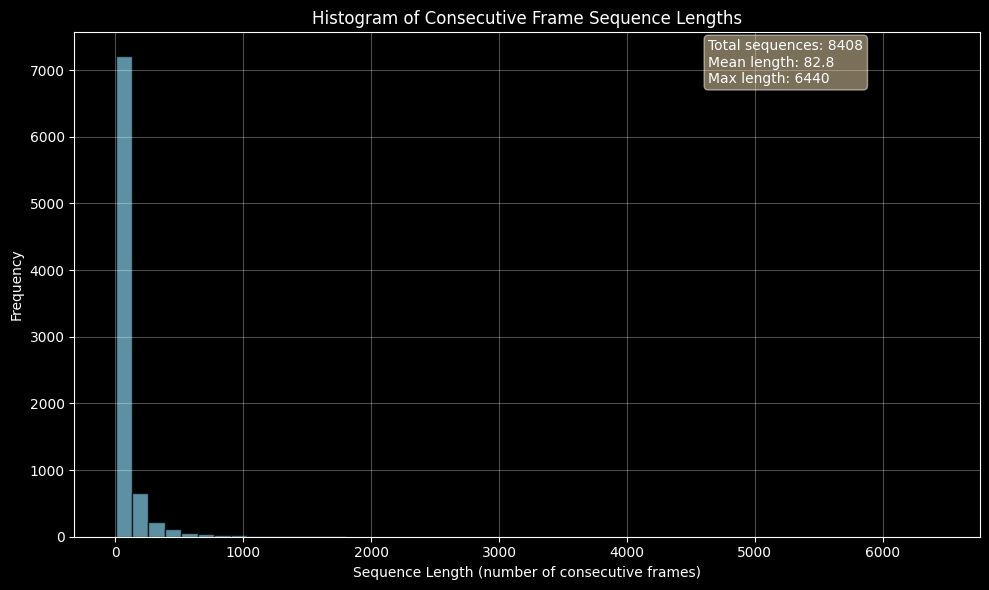

Merged 696179 rows into 8408 sequences
8408

Sequence Summary for track 9 and threshold 0.99:
Total sequences: 8408
Average sequence length: 82.8
Longest sequence: 6440 frames
Average confidence: 0.992
8408
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AQQZFV2ALD_track_9.parquet
Total frames: 633390
Number of unique sequences: 5821
Sequence lengths - Min: 1, Max: 7015, Mean: 108.8


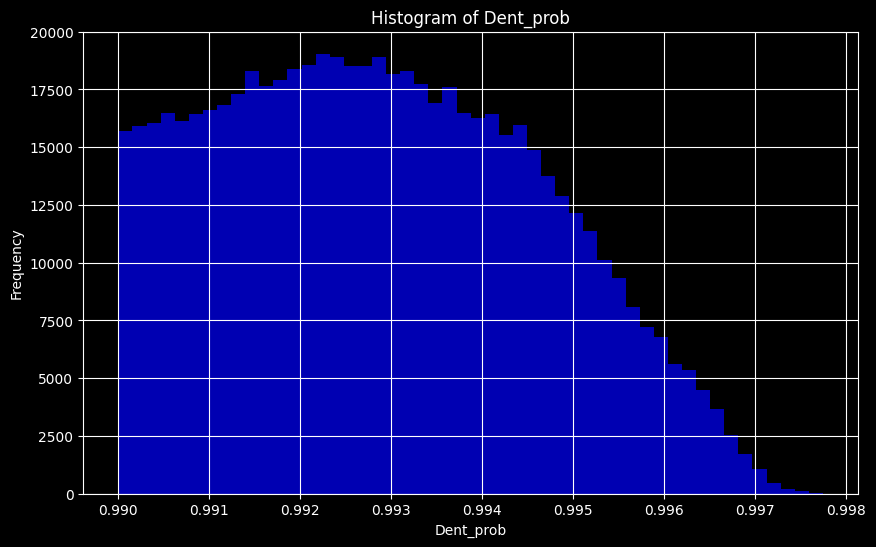

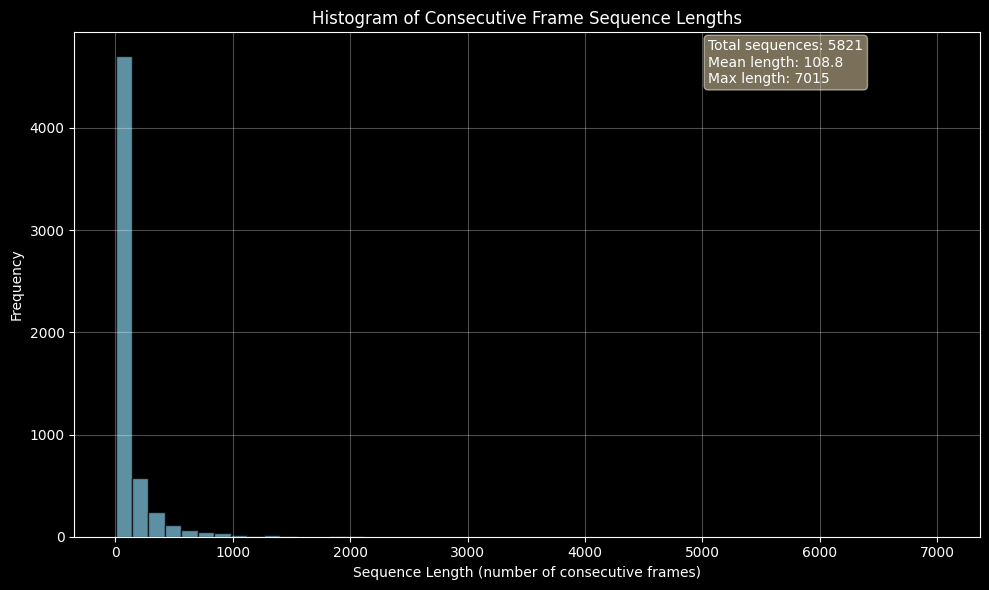

Merged 633390 rows into 5821 sequences
5821

Sequence Summary for track 10 and threshold 0.99:
Total sequences: 5821
Average sequence length: 108.8
Longest sequence: 7015 frames
Average confidence: 0.992
5821
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AQQZFV2ALD_track_10.parquet
Total frames: 386422
Number of unique sequences: 3942
Sequence lengths - Min: 1, Max: 5355, Mean: 98.0


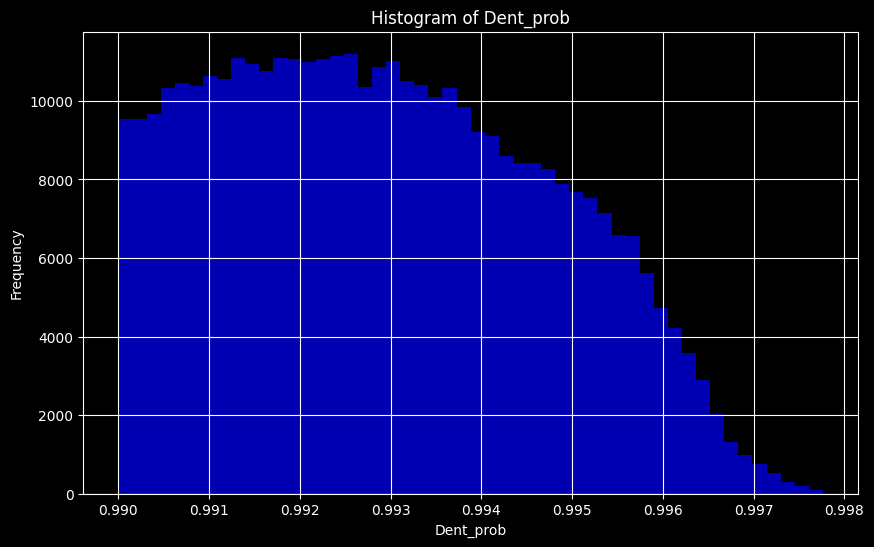

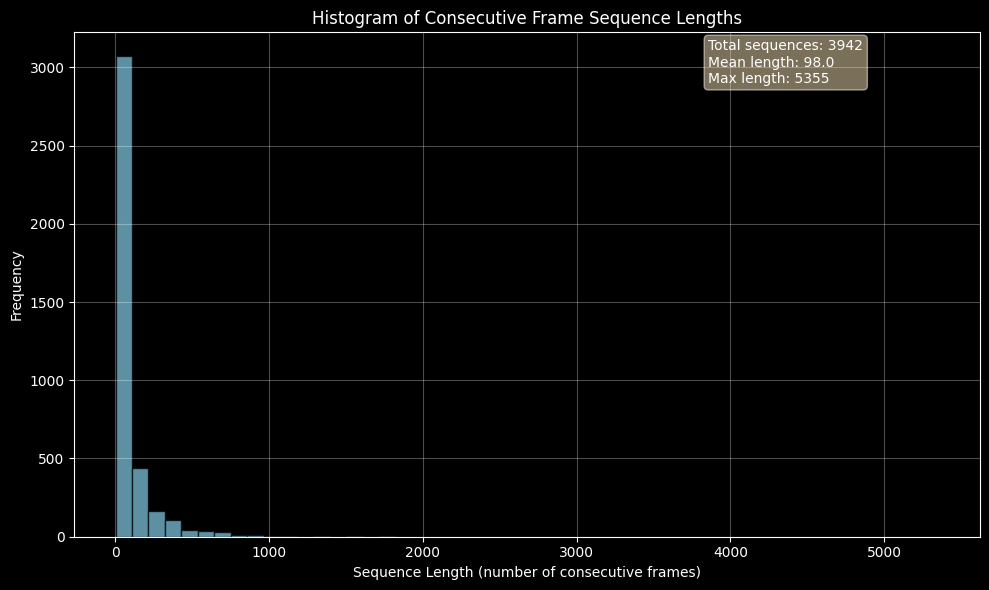

Merged 386422 rows into 3942 sequences
3942

Sequence Summary for track 11 and threshold 0.99:
Total sequences: 3942
Average sequence length: 98.0
Longest sequence: 5355 frames
Average confidence: 0.992
3942
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AQQZFV2ALD_track_11.parquet
Total frames: 350893
Number of unique sequences: 3806
Sequence lengths - Min: 1, Max: 3370, Mean: 92.2


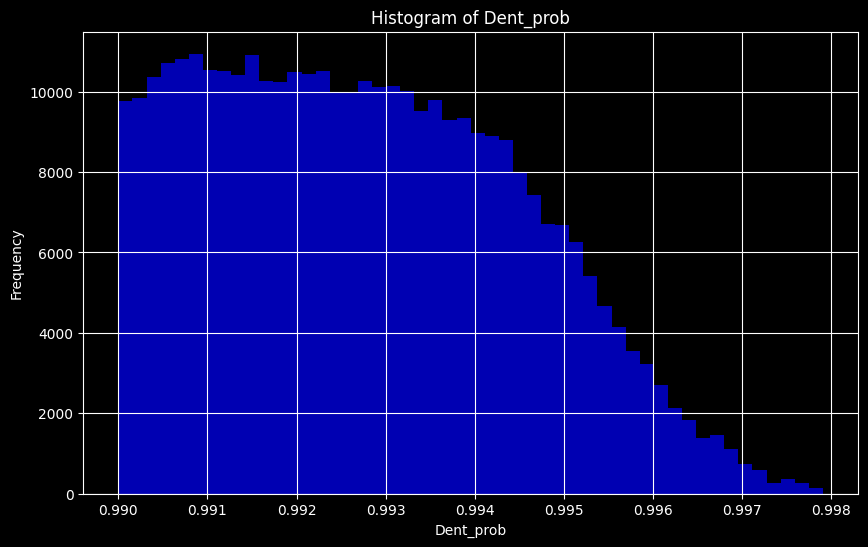

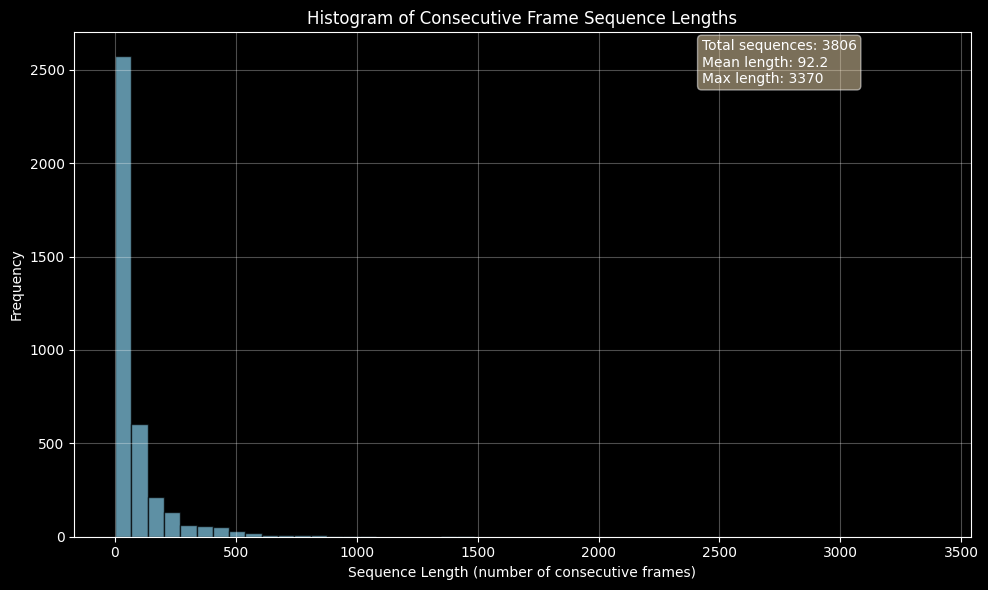

Merged 350893 rows into 3806 sequences
3806

Sequence Summary for track 12 and threshold 0.99:
Total sequences: 3806
Average sequence length: 92.2
Longest sequence: 3370 frames
Average confidence: 0.992
3806
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AQQZFV2ALD_track_12.parquet
No valid data found for frame_range=None
No data for track 13 at threshold 0.99, skipping.
Total frames: 471276
Number of unique sequences: 5018
Sequence lengths - Min: 1, Max: 3835, Mean: 93.9


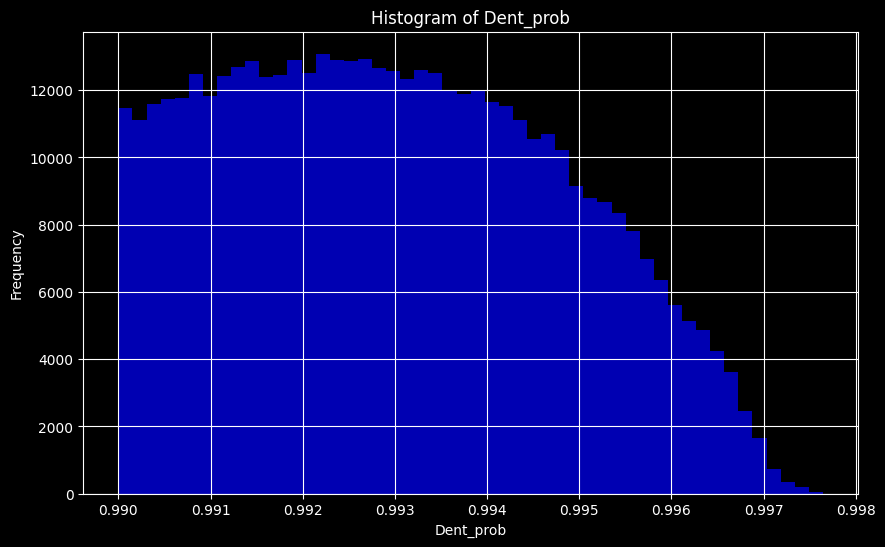

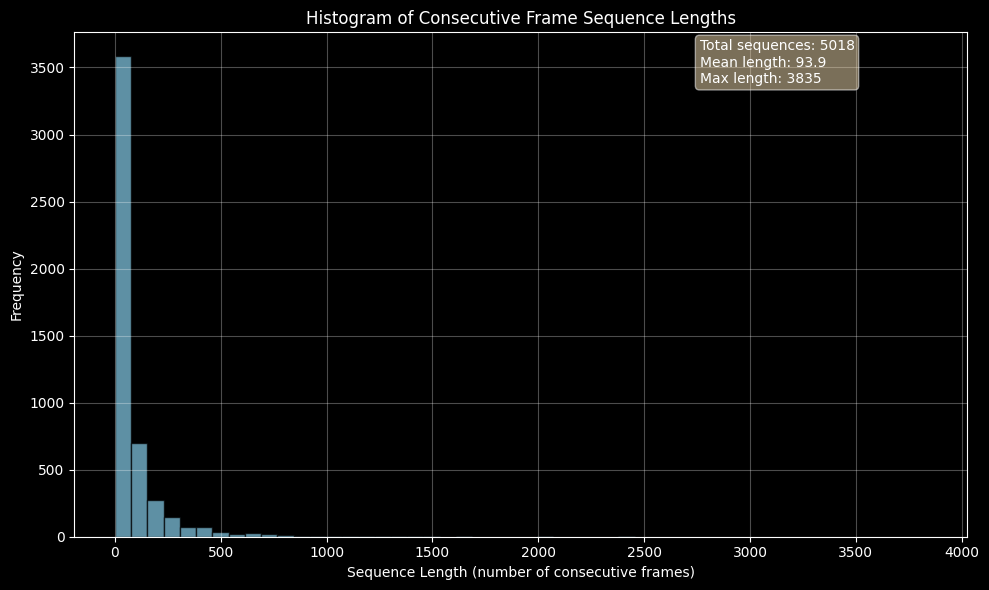

Merged 471276 rows into 5018 sequences
5018

Sequence Summary for track 14 and threshold 0.99:
Total sequences: 5018
Average sequence length: 93.9
Longest sequence: 3835 frames
Average confidence: 0.992
5018
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AQQZFV2ALD_track_14.parquet
Total frames: 377753
Number of unique sequences: 3707
Sequence lengths - Min: 1, Max: 6355, Mean: 101.9


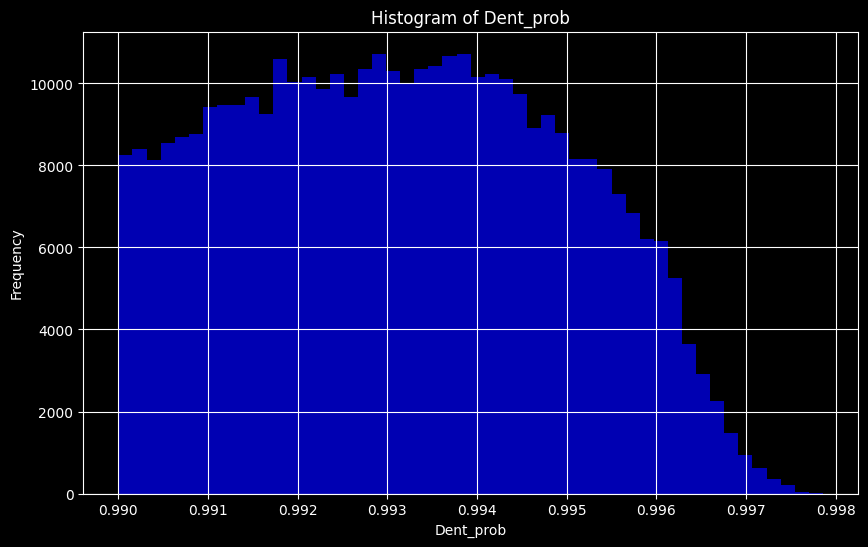

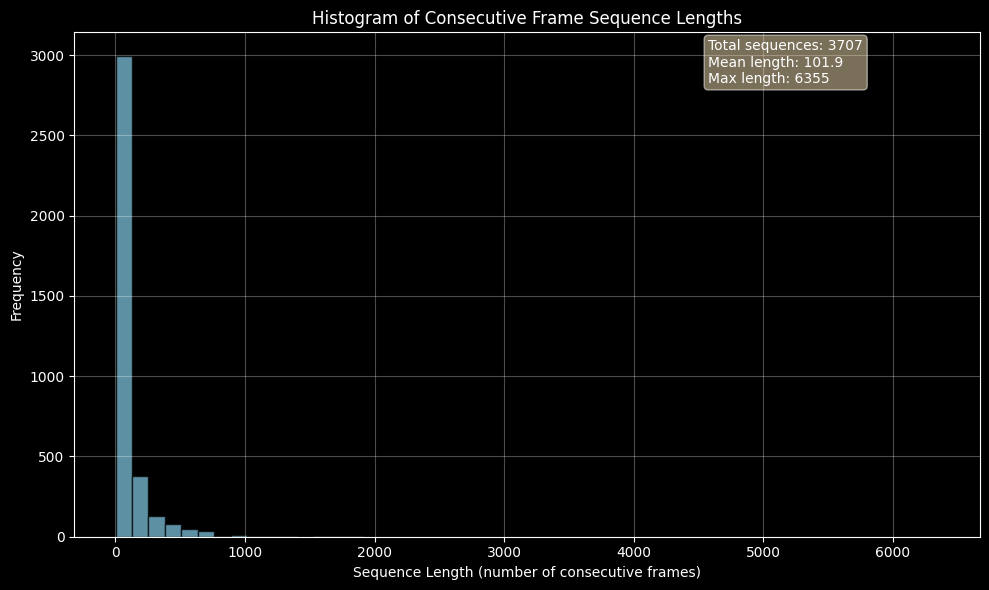

Merged 377753 rows into 3707 sequences
3707

Sequence Summary for track 15 and threshold 0.99:
Total sequences: 3707
Average sequence length: 101.9
Longest sequence: 6355 frames
Average confidence: 0.992
3707
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AQQZFV2ALD_track_15.parquet
Total frames: 340781
Number of unique sequences: 3363
Sequence lengths - Min: 1, Max: 2545, Mean: 101.3


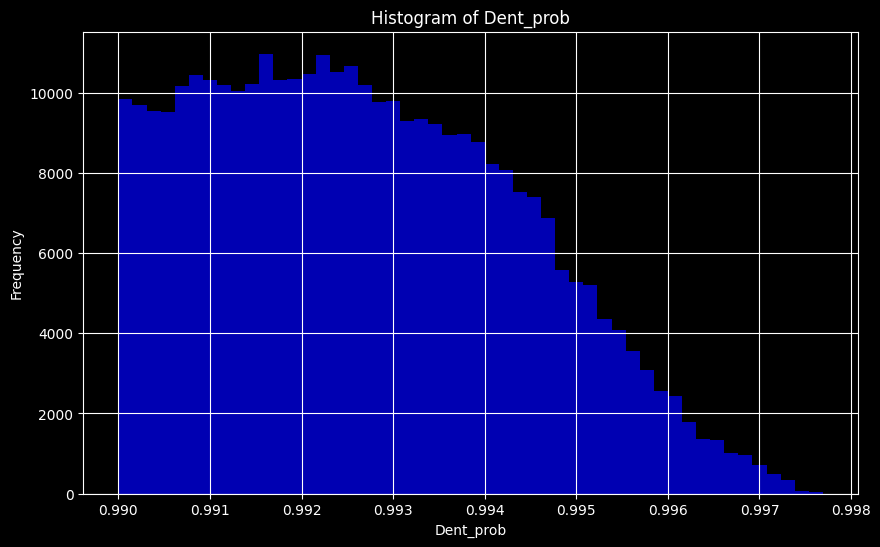

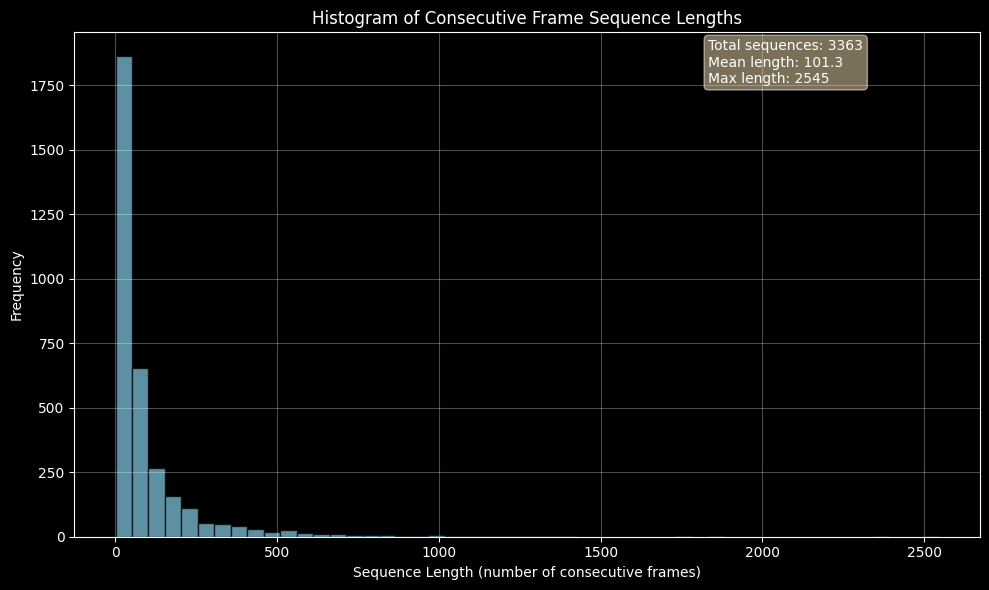

Merged 340781 rows into 3363 sequences
3363

Sequence Summary for track 16 and threshold 0.99:
Total sequences: 3363
Average sequence length: 101.3
Longest sequence: 2545 frames
Average confidence: 0.992
3363
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AQQZFV2ALD_track_16.parquet
Total frames: 577283
Number of unique sequences: 6152
Sequence lengths - Min: 1, Max: 4465, Mean: 93.8


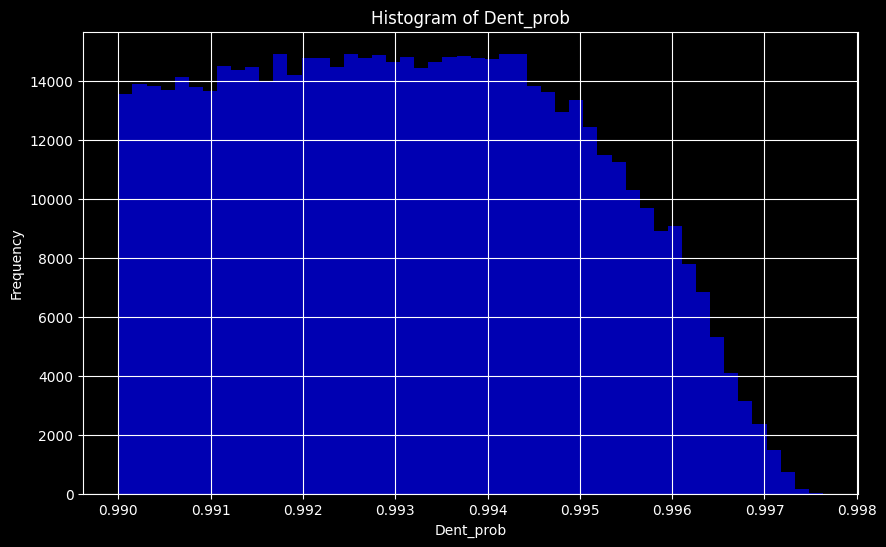

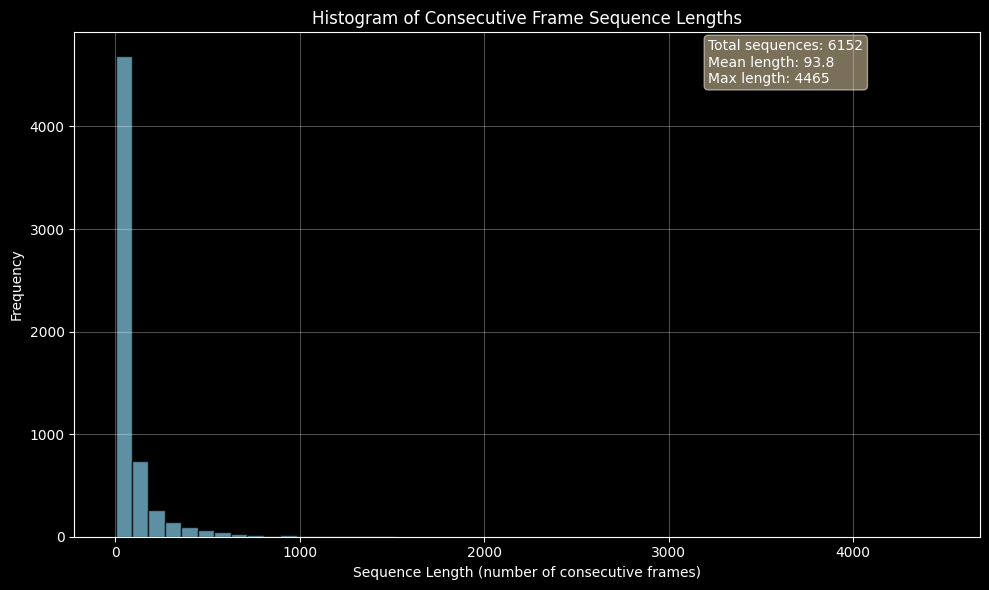

Merged 577283 rows into 6152 sequences
6152

Sequence Summary for track 17 and threshold 0.99:
Total sequences: 6152
Average sequence length: 93.8
Longest sequence: 4465 frames
Average confidence: 0.992
6152
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AQQZFV2ALD_track_17.parquet
Total frames: 217882
Number of unique sequences: 1920
Sequence lengths - Min: 1, Max: 2645, Mean: 113.5


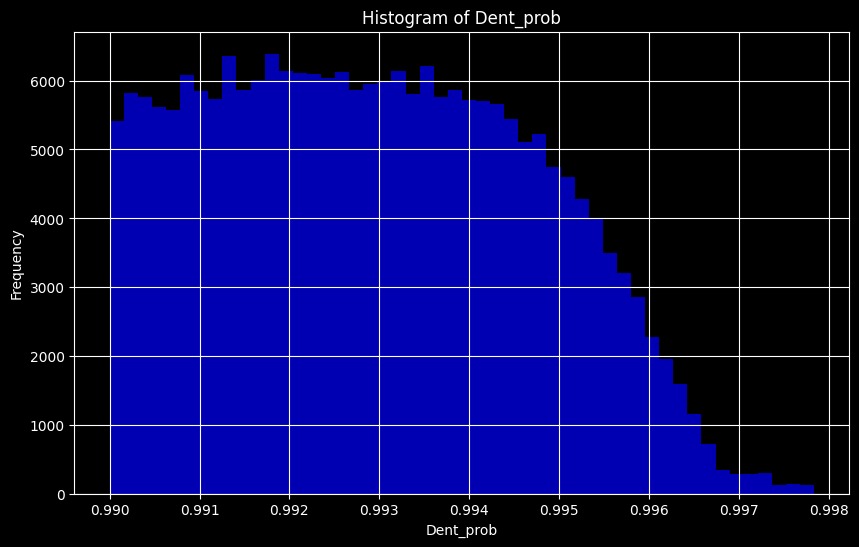

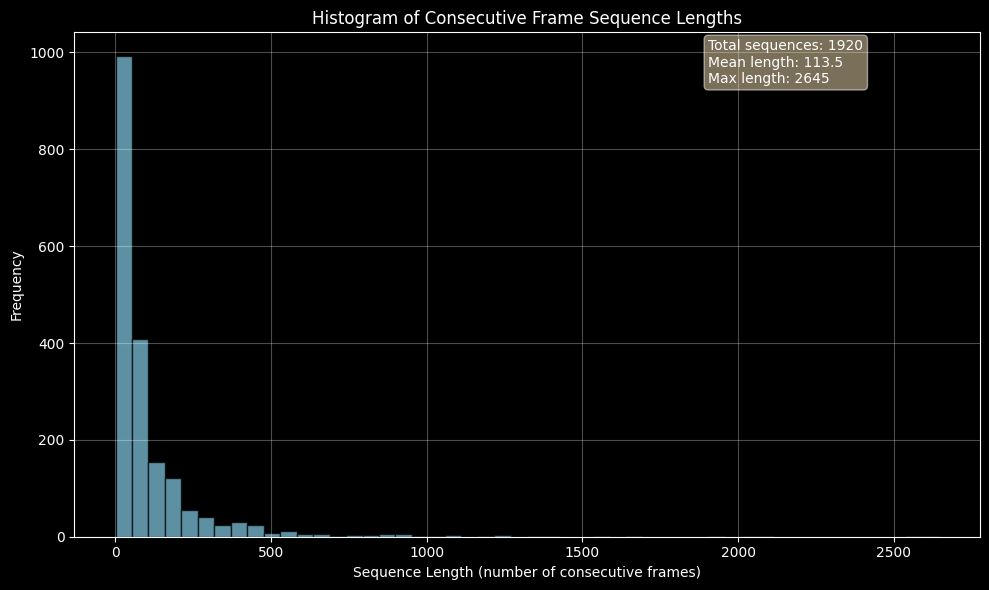

Merged 217882 rows into 1920 sequences
1920

Sequence Summary for track 18 and threshold 0.99:
Total sequences: 1920
Average sequence length: 113.5
Longest sequence: 2645 frames
Average confidence: 0.992
1920
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AQQZFV2ALD_track_18.parquet
Total frames: 353992
Number of unique sequences: 3485
Sequence lengths - Min: 1, Max: 4730, Mean: 101.6


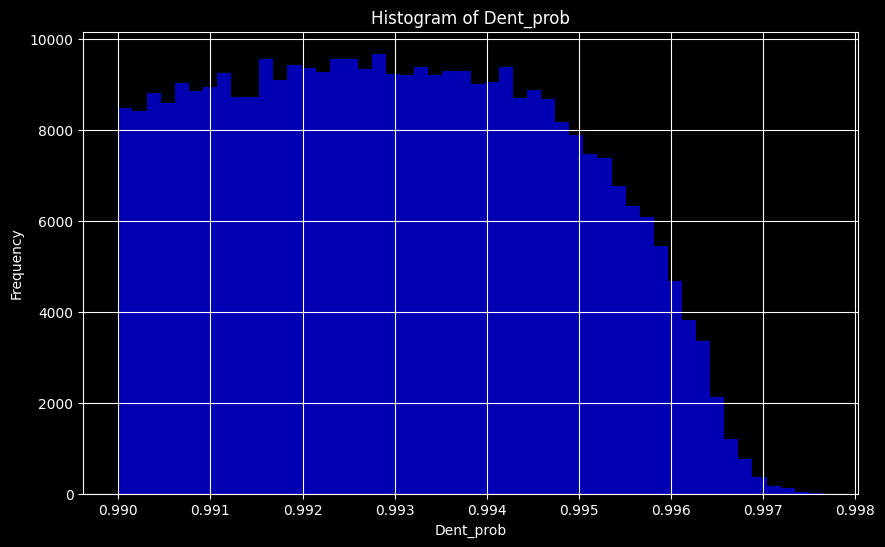

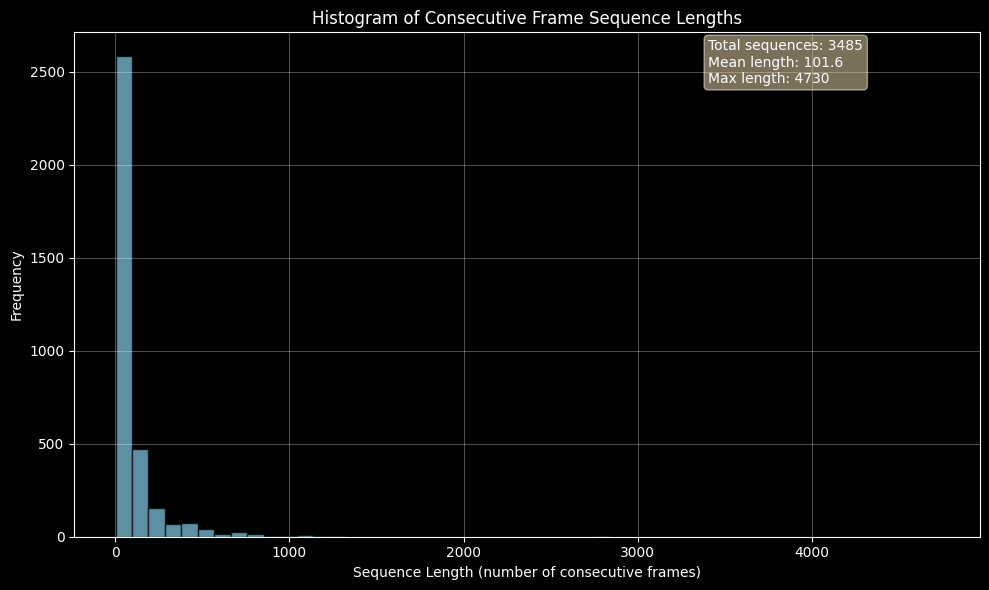

Merged 353992 rows into 3485 sequences
3485

Sequence Summary for track 19 and threshold 0.99:
Total sequences: 3485
Average sequence length: 101.6
Longest sequence: 4730 frames
Average confidence: 0.992
3485
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AQQZFV2ALD_track_19.parquet
Total frames: 382527
Number of unique sequences: 3686
Sequence lengths - Min: 1, Max: 4665, Mean: 103.8


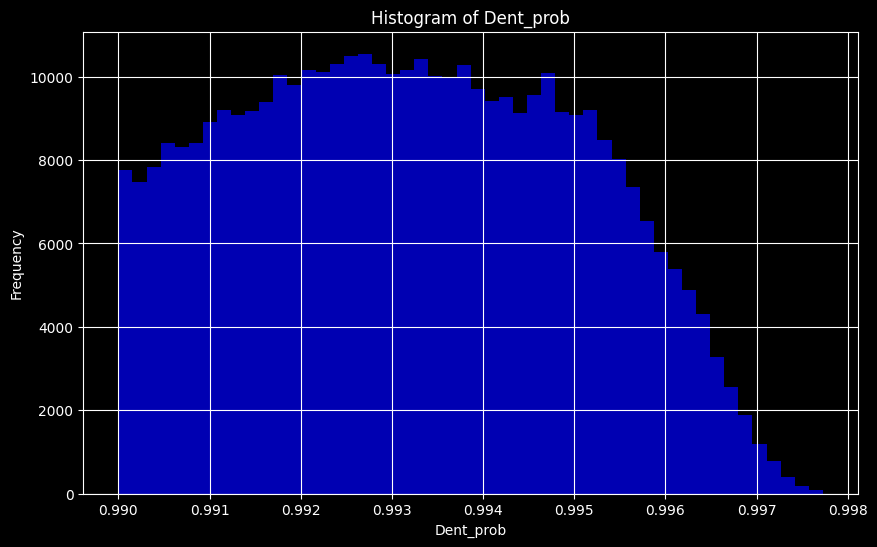

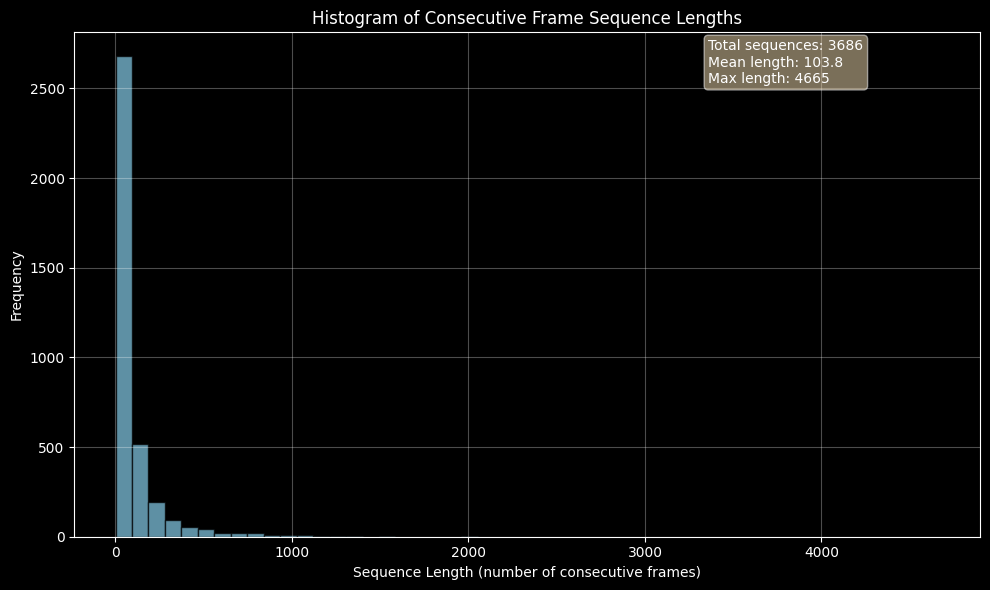

Merged 382527 rows into 3686 sequences
3686

Sequence Summary for track 20 and threshold 0.99:
Total sequences: 3686
Average sequence length: 103.8
Longest sequence: 4665 frames
Average confidence: 0.992
3686
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AQQZFV2ALD_track_20.parquet
Total frames: 385195
Number of unique sequences: 3397
Sequence lengths - Min: 1, Max: 2990, Mean: 113.4


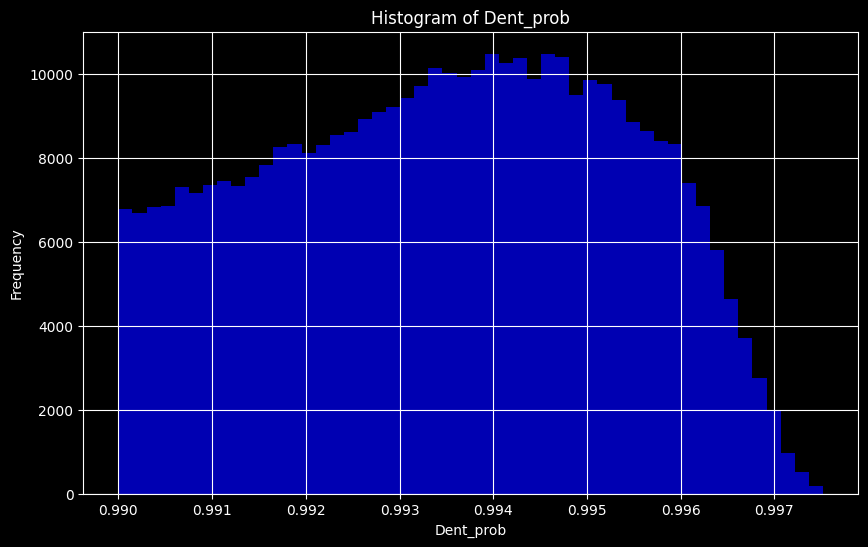

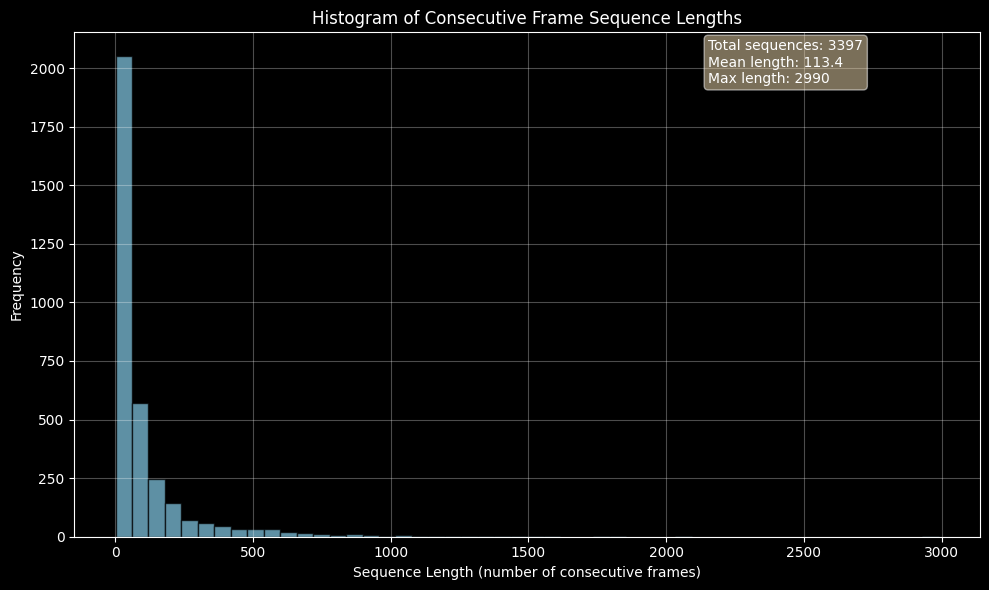

Merged 385195 rows into 3397 sequences
3397

Sequence Summary for track 21 and threshold 0.99:
Total sequences: 3397
Average sequence length: 113.4
Longest sequence: 2990 frames
Average confidence: 0.992
3397
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AQQZFV2ALD_track_21.parquet
Total frames: 373714
Number of unique sequences: 3667
Sequence lengths - Min: 1, Max: 2755, Mean: 101.9


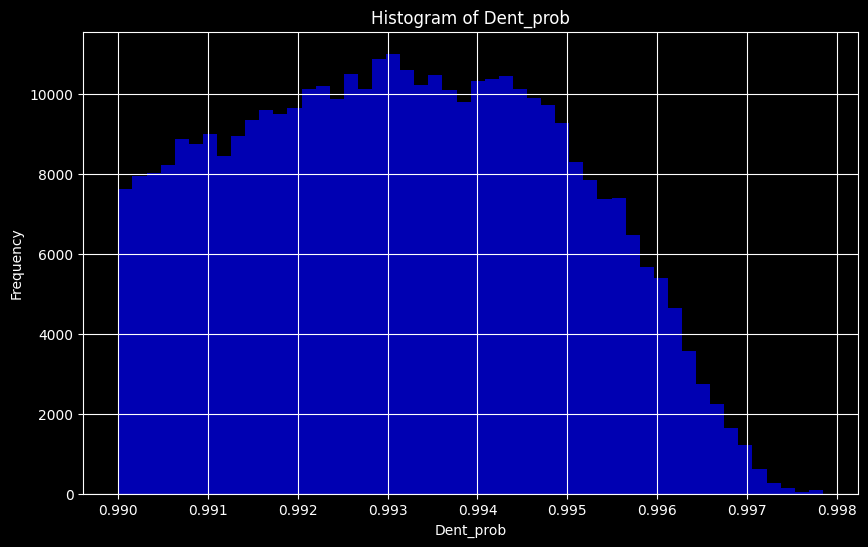

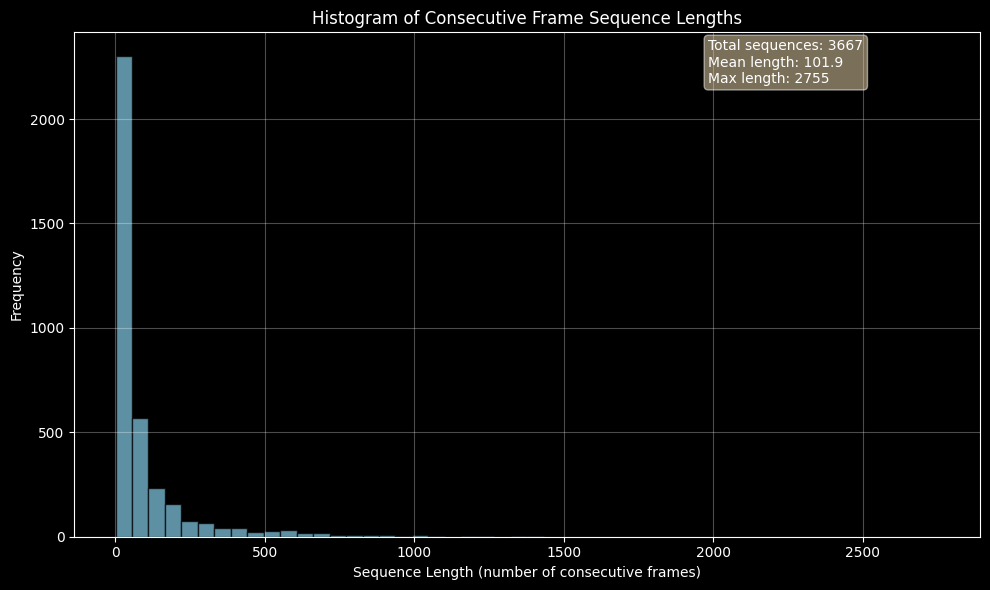

Merged 373714 rows into 3667 sequences
3667

Sequence Summary for track 22 and threshold 0.99:
Total sequences: 3667
Average sequence length: 101.9
Longest sequence: 2755 frames
Average confidence: 0.992
3667
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AQQZFV2ALD_track_22.parquet
Total frames: 276552
Number of unique sequences: 2566
Sequence lengths - Min: 1, Max: 3446, Mean: 107.8


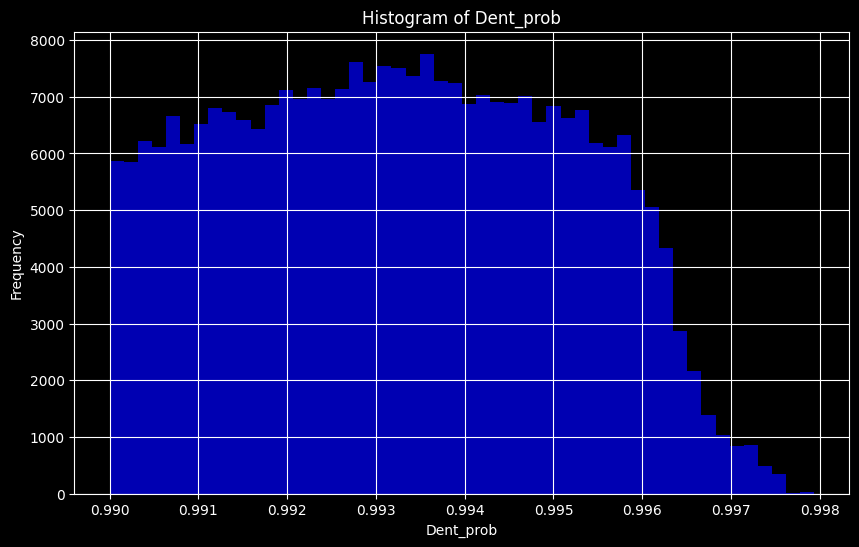

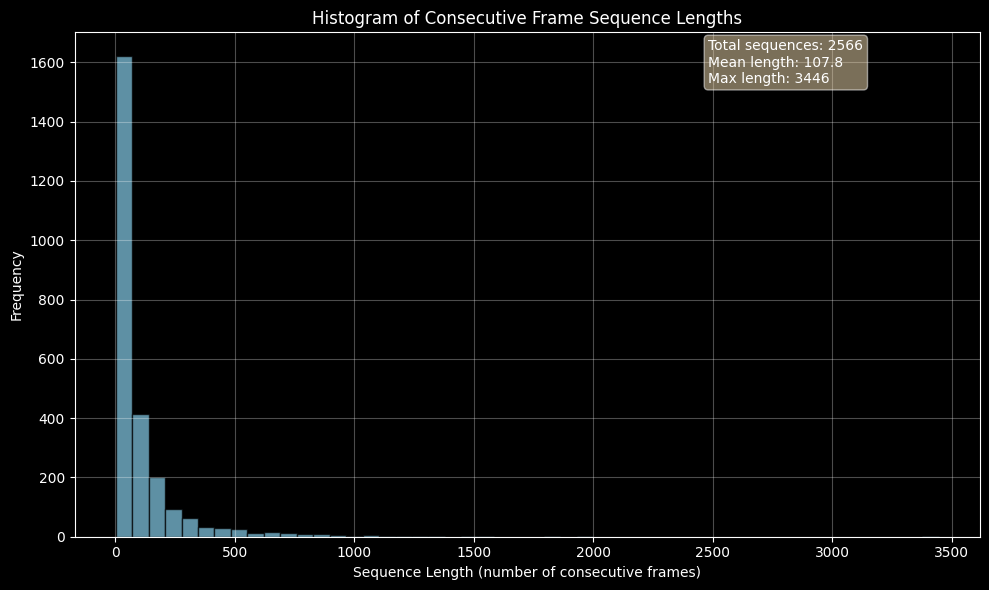

Merged 276552 rows into 2566 sequences
2566

Sequence Summary for track 23 and threshold 0.99:
Total sequences: 2566
Average sequence length: 107.8
Longest sequence: 3446 frames
Average confidence: 0.992
2566
DataFrame saved to s3://dent-dev/dent_bookmarks/UltrasoundDent_bookmarks_0AQQZFV2ALD_track_23.parquet


In [11]:
threshold = 0.99
num_tracks = 24
bucket_name = "dent-dev"

for track_idx in range(0, num_tracks):
    s3_key = f"dent_bookmarks/UltrasoundDent_bookmarks_{inspection_id}_track_{track_idx}.parquet"
    filtered_df = create_df(track_idx=track_idx, threshold=threshold)
    if filtered_df.empty:
        print(f"No data for track {track_idx} at threshold {threshold}, skipping.")
        continue
    # Create a histogram of dent_prob
    plt.style.use('dark_background')
    plt.figure(figsize=(10, 6))
    plt.hist(filtered_df['dent_prob'], bins=50, color='blue', alpha=0.7)
    plt.title('Histogram of Dent_prob')
    plt.xlabel('Dent_prob')
    plt.ylabel('Frequency')
    plt.grid(True)  

    count = len(filtered_df)
    df_with_ranges, num_sequences, seq_lengths = analyze_frame_sequences(filtered_df)


    sequence_df = merge_sequences_to_single_row(df_with_ranges, inspection_id=inspection_id)
    print(len(sequence_df))

    # Optional: Show summary statistics
    print(f"\nSequence Summary for track {track_idx} and threshold {threshold}:")
    print(f"Total sequences: {len(sequence_df)}")
    print(f"Average sequence length: {sequence_df['sequence_length'].mean():.1f}")
    print(f"Longest sequence: {sequence_df['sequence_length'].max()} frames")
    print(f"Average confidence: {sequence_df['avg_confidence'].mean():.3f}")
    print(len(sequence_df))

    save_df_to_s3_parquet(sequence_df, bucket_name, s3_key)
